In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from plotimagesc import imagesc1
from plotimagesc import add_colorbar
from generate_data_Cami_AC import Reading_Cami_data_AC
import scipy.io as spio
device = torch.device("cpu:0")

In [2]:
nz= 71
nx= 201

In [3]:
# Loading line1 results_arc_arc
vmodel1_list  = torch.load("./line4/arc/step2_monitor_vs/vmodel1_list.pt")
vmodel2_list  = torch.load("./line4/arc/step2_monitor_vs/vmodel2_list.pt")
vmodel3_list  = torch.load("./line4/arc/step2_monitor_vs/vmodel3_list.pt")
train_loss_history  = torch.load("./line4/arc/step2_monitor_vs/train_loss_history.pt")

In [4]:
from H_V_Smooth import H_Smooth
smooth_value = 3
H_Smooth_fun = H_Smooth(vmodel1_list[-1].squeeze(), smooth_value)
vp_smooth = H_Smooth_fun()
H_Smooth_fun = H_Smooth(vmodel2_list[-1].squeeze(), smooth_value)
vs_smooth = H_Smooth_fun()
H_Smooth_fun = H_Smooth(vmodel3_list[-1].squeeze(), smooth_value)
rho_smooth = H_Smooth_fun()


In [5]:
from scipy.ndimage import gaussian_filter
vp_vs_den_mat = loadmat("./vp_vs_den.mat")
vp_well_true = vp_vs_den_mat['vp']
vs_well_true = vp_vs_den_mat['vs']
rho_well_true = vp_vs_den_mat['den']

print(vs_well_true.min())

vp_well_initial_model = np.ones([nz, nx])
vs_well_initial_model = np.ones([nz, nx])
rho_well_initial_model = np.ones([nz, nx])

for iii in range(nx):
    vp_well_initial_model[:, iii] = vp_well_true[:nz].squeeze()
    
for iii in range(nx):
    vs_well_initial_model[:, iii] = vs_well_true[:nz].squeeze()


for iii in range(nx):
    rho_well_initial_model[:, iii] = rho_well_true[:nz].squeeze()

vp_init = gaussian_filter(vp_well_initial_model, 5)
vs_init = gaussian_filter(vs_well_initial_model, 5)
rho_init = gaussian_filter(rho_well_initial_model, 5)
print(vp_well_true.max(), vp_well_true.min(),vs_well_true.max(), vs_well_true.min(),rho_well_true.max(), rho_well_true.min())

121.89655925226268
3278.688524590164 1811.8746759116152 1644.7368421052631 121.89655925226268 2477.0373661417316 1869.653433070866


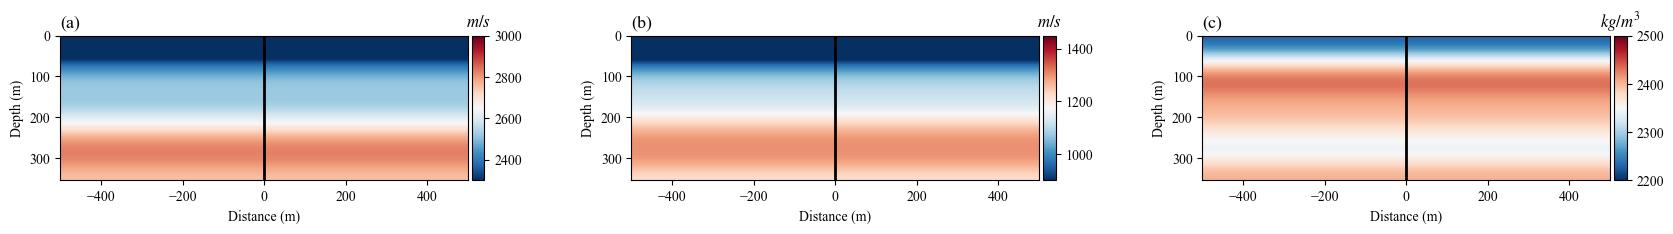

In [6]:
color_bar = 'RdBu_r'
font_size = 10
aspect_num = 1
std_scale = 3
dx = 5
dz =5
nx = 201

smoothing_parameter = 0
plot_offset = 0
scaled_dim=0
left_location = (nx//2-scaled_dim)
right_location = (nx//2-scaled_dim)

vmin_value =1000

vmin_value_vp = vp_smooth[5:,:].min()
vmax_value_vp = vp_smooth[10:,:].max()

vmin_value_vs = vs_smooth[5:,:].min()
vmax_value_vs = vs_smooth[5:,:].max()

vmin_value_rho = rho_smooth[:,:].min()
vmax_value_rho = rho_smooth[:,:].max()


fig = plt.figure(figsize=(20, 7))
gs = fig.add_gridspec(1, 3)
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(vp_init[:, scaled_dim:nx-scaled_dim],extent=[-left_location*dx, right_location*dx, nz*dz, 0], aspect=aspect_num, cmap=color_bar, vmin=2300,vmax=3000)
ax.axvline(x=0, linewidth=2, color='k')
ax.set_title("(a)", fontsize=font_size+3, loc='left')
#ax.set_xticks([])
ax.set_xlabel("Distance (m)", fontsize=font_size)
ax.set_ylabel("Depth (m)", fontsize=font_size)
ax.tick_params(axis='x', labelsize=font_size)
ax.tick_params(axis='y', labelsize=font_size)
cbar = add_colorbar(ax, im, ax.transAxes, width="3%", ctitle='$m/s$')

ax = fig.add_subplot(gs[0, 1])
im = ax.imshow(vs_init[:, scaled_dim:nx-scaled_dim],extent=[-left_location*dx, right_location*dx, nz*dz, 0], aspect=aspect_num, cmap=color_bar, vmin=900, vmax=1450)
ax.axvline(x=0, linewidth=2, color='k')
ax.set_title("(b)", fontsize=font_size+3, loc='left')
#ax.set_xticks([])
ax.set_xlabel("Distance (m)", fontsize=font_size)
ax.set_ylabel("Depth (m)", fontsize=font_size)
ax.tick_params(axis='x', labelsize=font_size)
ax.tick_params(axis='y', labelsize=font_size)
cbar = add_colorbar(ax, im, ax.transAxes, width="3%", ctitle='$m/s$')



ax = fig.add_subplot(gs[0, 2])
im = ax.imshow(rho_init[:, scaled_dim:nx-scaled_dim],extent=[-left_location*dx, right_location*dx, nz*dz, 0], aspect=aspect_num, cmap=color_bar, vmin=2200,vmax=2500)
ax.set_title("(c)", fontsize=font_size+3, loc='left')
ax.axvline(x=0, linewidth=2, color='k')
#ax.set_xticks([])
ax.set_xlabel("Distance (m)", fontsize=font_size)
ax.set_ylabel("Depth (m)", fontsize=font_size)
ax.tick_params(axis='x', labelsize=font_size)
ax.tick_params(axis='y', labelsize=font_size)

cbar = add_colorbar(ax, im, ax.transAxes, width="3%", ctitle='$kg/m^{3}$')

plt.subplots_adjust(left=0.125,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.1)

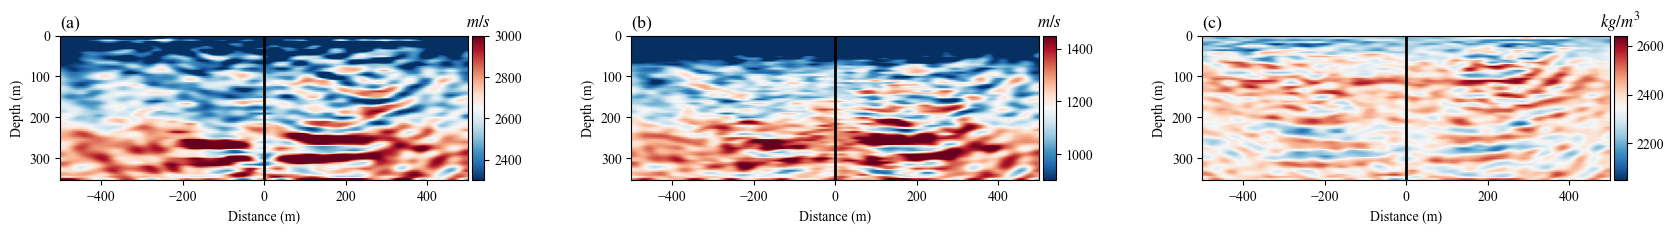

In [7]:

fig = plt.figure(figsize=(20, 7))
gs = fig.add_gridspec(1, 3)
ax = fig.add_subplot(gs[0, 0])
im = ax.imshow(vp_smooth[:, scaled_dim:nx-scaled_dim],extent=[-left_location*dx, right_location*dx, nz*dz, 0], aspect=aspect_num, cmap=color_bar, vmin=2300,vmax=3000)
ax.axvline(x=0, linewidth=2, color='k')
ax.set_title("(a)", fontsize=font_size+3, loc='left')
#ax.set_xticks([])
ax.set_xlabel("Distance (m)", fontsize=font_size)
ax.set_ylabel("Depth (m)", fontsize=font_size)
ax.tick_params(axis='x', labelsize=font_size)
ax.tick_params(axis='y', labelsize=font_size)
cbar = add_colorbar(ax, im, ax.transAxes, width="3%", ctitle='$m/s$')

ax = fig.add_subplot(gs[0, 1])
im = ax.imshow(vs_smooth[:, scaled_dim:nx-scaled_dim],extent=[-left_location*dx, right_location*dx, nz*dz, 0], aspect=aspect_num, cmap=color_bar, vmin=900, vmax=1450)
ax.axvline(x=0, linewidth=2, color='k')
ax.set_title("(b)", fontsize=font_size+3, loc='left')
#ax.set_xticks([])
ax.set_xlabel("Distance (m)", fontsize=font_size)
ax.set_ylabel("Depth (m)", fontsize=font_size)
ax.tick_params(axis='x', labelsize=font_size)
ax.tick_params(axis='y', labelsize=font_size)
cbar = add_colorbar(ax, im, ax.transAxes, width="3%", ctitle='$m/s$')



ax = fig.add_subplot(gs[0, 2])
im = ax.imshow(rho_smooth[:, scaled_dim:nx-scaled_dim],extent=[-left_location*dx, right_location*dx, nz*dz, 0], aspect=aspect_num, cmap=color_bar)#, vmin=2300,vmax=2500)
ax.set_title("(c)", fontsize=font_size+3, loc='left')
ax.axvline(x=0, linewidth=2, color='k')
#ax.set_xticks([])
ax.set_xlabel("Distance (m)", fontsize=font_size)
ax.set_ylabel("Depth (m)", fontsize=font_size)
ax.tick_params(axis='x', labelsize=font_size)
ax.tick_params(axis='y', labelsize=font_size)

cbar = add_colorbar(ax, im, ax.transAxes, width="3%", ctitle='$kg/m^{3}$')

plt.subplots_adjust(left=0.125,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.1)

In [1]:
font_size = 12
dz = 5
z = np.arange(0, nz)*dz
profile_index = int(nx//2)+15
line_width = 3
smoothing_factor = 1

fig = plt.figure(figsize=(12, 6))

gs = fig.add_gridspec(1, 3)
ax = fig.add_subplot(gs[0, 0])

ax.plot(vp_well_initial_model[:nz,profile_index],z,linewidth=line_width, color = 'dimgray',linestyle="-", label='Well-log')
ax.plot(((vp_smooth[:,profile_index])), z, linewidth=line_width,color ='darkblue', linestyle="--",label='Inversion')
ax.plot(((vp_init[:,profile_index])), z, linewidth=line_width,  color = 'firebrick', linestyle=":",label='Initial')
ax.set_title('(a)', loc='left', fontsize =font_size)
ax.set_ylabel("Depth (m)", fontsize =font_size)
ax.set_xlabel(r"$V_p (\mathrm{m/s})$", fontsize =font_size)
ax.tick_params(axis='x', labelsize=font_size)
ax.tick_params(axis='y', labelsize=font_size)
ax.legend(loc='best', fontsize=font_size-2)
ax.invert_yaxis()
ax.grid()
ax.set_xlim(1800, 3500)
ax.set_ylim(350, 0)

ax = fig.add_subplot(gs[0, 1])
ax.plot(vs_well_initial_model[:nz,profile_index], z,  linewidth=line_width, color = 'dimgray', linestyle="-",)
ax.plot(((vs_smooth[:,profile_index])), z, linewidth=line_width,color = 'darkblue', linestyle="--",)
ax.plot(((vs_init[:,profile_index])), z, linewidth=line_width,color = 'firebrick', linestyle=":",)

ax.set_title('(b)', loc='left', fontsize =font_size)
ax.set_ylabel("Depth (m)", fontsize =font_size)
ax.set_xlabel(r"$V_s (\mathrm{m/s}$)", fontsize =font_size)
ax.tick_params(axis='x', labelsize=font_size)
ax.tick_params(axis='y', labelsize=font_size)
ax.invert_yaxis()
ax.grid()
ax.set_xlim(500, 1800)
ax.set_ylim(350, 0)

profile_index = int(nx//2)+10

ax = fig.add_subplot(gs[0, 2])
ax.plot(rho_well_initial_model[:nz,profile_index], z,  linewidth=line_width, color = 'dimgray', linestyle="-",)
ax.plot(((rho_smooth[:,profile_index])), z, linewidth=line_width,color = 'darkblue', linestyle="--",)
ax.plot(((rho_init[:,profile_index])), z, linewidth=line_width,color = 'firebrick', linestyle=":",)
ax.set_title('(c)', loc='left', fontsize =font_size)
ax.set_ylabel("Depth (m)", fontsize =font_size)
ax.set_xlabel(r"$\rho (\mathrm{kg/m^{3}})$", fontsize =font_size)
ax.tick_params(axis='x', labelsize=font_size)
ax.tick_params(axis='y', labelsize=font_size)
ax.invert_yaxis()
ax.grid()
ax.set_xlim(1900, 2600)
ax.set_ylim(350, 0)


plt.subplots_adjust(left=0.125,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)


NameError: name 'np' is not defined

train_loss_history 500


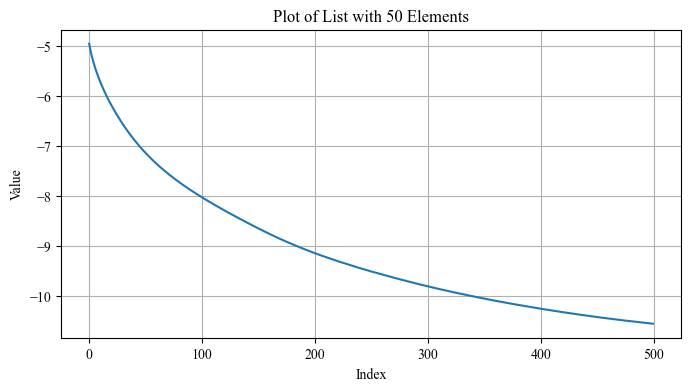

In [9]:

print("train_loss_history", len(train_loss_history))
plt.figure(figsize=(8, 4))
plt.plot(train_loss_history)  # 画线+点
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Plot of List with 50 Elements')
plt.grid(True)
plt.show()

In [10]:
# load field seismic data
dt = 0.0005
nt = 981
t = dt * np.arange(0, nt)


Snowflake_line= spio.loadmat('./line4/line4_accel_V2.mat', squeeze_me=True)
data_vert  = torch.as_tensor(Snowflake_line['baselineV_ns_nt_nr'], dtype=torch.float32)
data_hmax  = torch.as_tensor(Snowflake_line['baselineH_ns_nt_nr'], dtype=torch.float32)
mute_direc = torch.as_tensor(Snowflake_line['mute_dh5'], dtype=torch.float32).T+100
mute_refl = mute_direc-20
# mute_refl = mute_direc-200
depth = Snowflake_line['Depthdh']

Reading_Cami_data_AC_fun = Reading_Cami_data_AC(data_vert=data_vert,
                                          data_hmax=data_hmax,
                                          mute=mute_refl,
                                          mute_type=2, # 1 for directwave, 2 for reflective wave
                                          nt=nt,
                                          dt= 0.0005,
                                          dr = 5,
                                          cut_off_freq = 60,
                                          order = 8,                                          
                                          device=device)
shots_obs_x, shots_obs_z = Reading_Cami_data_AC_fun()



shot_offset_array=np.array(Snowflake_line['offset'])
print(shot_offset_array)
xs_AC = []
for i in range(shot_offset_array.shape[0]):
    if shot_offset_array[i]<=0:
        sx_index = int((500 - (-shot_offset_array[i]))/5)
    else:
        sx_index = int((500 +(shot_offset_array[i]))/5)
    xs_AC.append(sx_index)
    
print(xs_AC)


subsampling_shots_num  = 1
xs = np.array(xs_AC)
zs = np.ones(xs.shape, dtype=np.int32) # source z-coordinate

print(shots_obs_x.shape, shots_obs_z.shape,xs.shape,zs.shape)
shots_obs_x=shots_obs_x[::10, :, :]
shots_obs_z=shots_obs_z[::10, :, :]
# shots_obs_DAS==shots_obs_DAS[1::10, :, :]
xs10=xs[::10]
zs10=zs[::10]
print(shots_obs_x.shape, shots_obs_z.shape,xs10.shape,zs10.shape)


(81, 981, 66)
(81, 981, 66)
input of butter filter shape torch.Size([81, 981, 66])
butter filter factor 0.06
input of butter filter shape torch.Size([81, 981, 66])
butter filter factor 0.06
[-480 -470 -460 -450 -440 -430 -420 -410 -400 -390 -380 -370 -360 -350
 -340 -330 -320 -310 -300 -290 -280 -270 -260 -250 -240 -230 -220 -210
 -200 -190 -180 -170 -160 -150 -140 -130 -120 -110 -100  -90  -80  -70
  -60  -50  -40  -30  -10   60   70   80   90  100  110  120  130  140
  150  160  170  180  190  200  210  220  230  240  250  260  270  280
  290  300  310  320  330  340  350  360  370  380  390]
[4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94, 98, 112, 114, 116, 118, 120, 122, 124, 126, 128, 130, 132, 134, 136, 138, 140, 142, 144, 146, 148, 150, 152, 154, 156, 158, 160, 162, 164, 166, 168, 170, 172, 174, 176, 178]
torch.Size([81, 981, 66]) torch.Size([81, 

(9, 981, 66)
(9, 981, 66)
torch.Size([9, 981, 66])
tensor(0.2737) tensor(-0.3409) 0.25871924 -0.28919807 0.25519267 -0.2861408


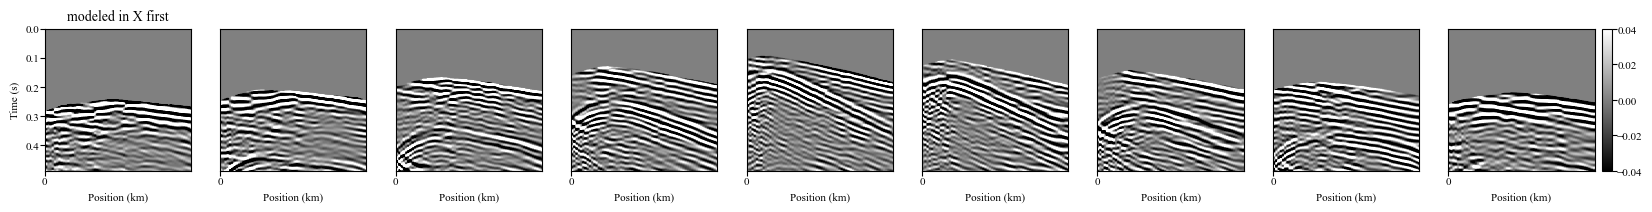

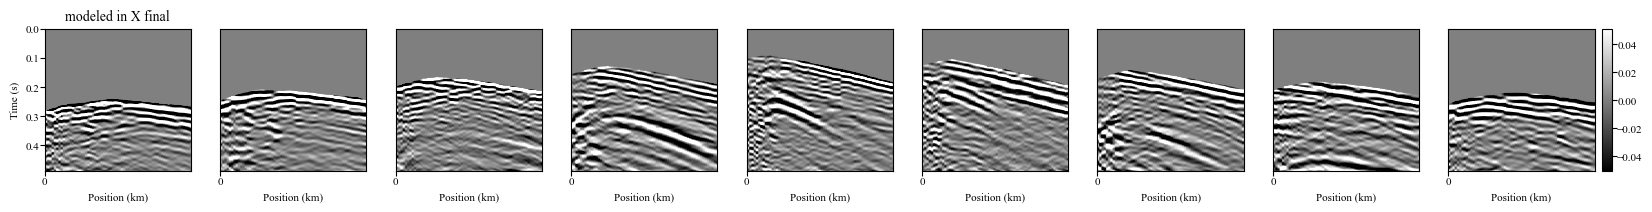

<Figure size 2000x500 with 0 Axes>

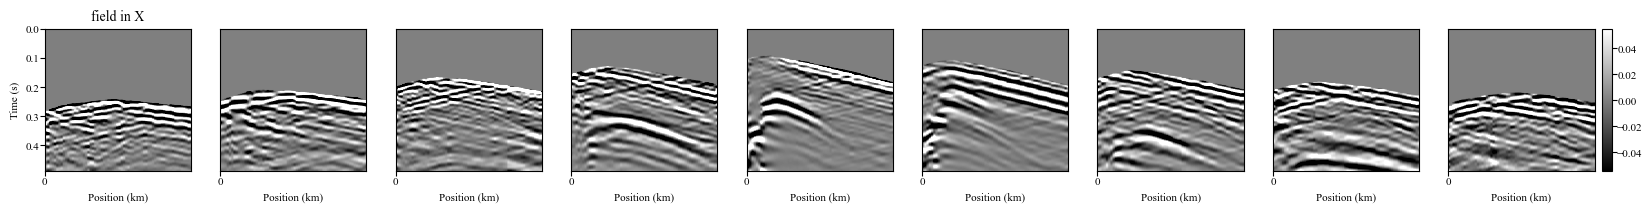

In [11]:
batchsize=9
# load modeled seismic data
segment_ytPred_x_AC  = torch.load('./line4/arc/step2_baseline_vs/segment_ytPred_x_normed_list_first.pt')
segment_ytPred_z_AC  = torch.load('./line4/arc/step2_baseline_vs/segment_ytPred_z_normed_list_first.pt')
segment_ytPred_x_ACf  = torch.load('./line4/arc/step2_baseline_vs/segment_ytPred_x_normed_list_final.pt')
segment_ytPred_z_ACf  = torch.load('./line4/arc/step2_baseline_vs/segment_ytPred_z_normed_list_final.pt')
nr=66

print(segment_ytPred_x_AC.shape)
shots=segment_ytPred_x_AC
fig=plt.figure(figsize=(20, 5))
imagesc1(fig,
        shots.reshape(1, batchsize, len(t), nr),
        vmin=-shots.max()/5,
        vmax=shots.max()/5,
        extent=[0, nx*dz/1000, t.max(), 0],
        aspect=2, #5
        nRows_nCols=(1,batchsize),
        cmap='gray',
        ylabel="Time (s)",
        xlabel="Position (km)",
        clabel="",
        xticks=np.arange(0., int(nx*dz/1000), 2),
        yticks=np.arange(0., t.max(), 0.1),
        fontsize=8,
        cbar_width="7%",
        cbar_height="100%",
        cbar_loc='lower left',
        titles = ["modeled in X first"])

print(segment_ytPred_x_ACf.shape)
shots=segment_ytPred_x_ACf
fig=plt.figure(figsize=(20, 5))
imagesc1(fig,
        shots.reshape(1, batchsize, len(t), nr),
        vmin=-shots.max()/5,
        vmax=shots.max()/5,
        extent=[0, nx*dz/1000, t.max(), 0],
        aspect=2, #5
        nRows_nCols=(1,batchsize),
        cmap='gray',
        ylabel="Time (s)",
        xlabel="Position (km)",
        clabel="",
        xticks=np.arange(0., int(nx*dz/1000), 2),
        yticks=np.arange(0., t.max(), 0.1),
        fontsize=8,
        cbar_width="7%",
        cbar_height="100%",
        cbar_loc='lower left',
        titles = ["modeled in X final"])

print(shots_obs_x.shape)
shots_obs_xbatch=shots_obs_x[:, :,:]
shots=shots_obs_xbatch
fig=plt.figure(figsize=(20, 5))
fig=plt.figure(figsize=(20, 5))
imagesc1(fig,
        shots.cpu().detach().numpy().reshape(1, batchsize, len(t), nr),
        vmin=-shots.max()/5,
        vmax=shots.max()/5,
        extent=[0, nx*dz/1000, t.max(), 0],
        aspect=2, #5
        nRows_nCols=(1,batchsize),
        cmap='gray',
        ylabel="Time (s)",
        xlabel="Position (km)",
        clabel="",
        xticks=np.arange(0., int(nx*dz/1000), 2),
        yticks=np.arange(0., t.max(), 0.1),
        fontsize=8,
        cbar_width="7%",
        cbar_height="100%",
        cbar_loc='lower left',
        titles = ["field in X"])

print(shots_obs_x.max(), shots_obs_x.min(),segment_ytPred_z_ACf.max(), segment_ytPred_z_ACf.min(),segment_ytPred_x_ACf.max(), segment_ytPred_x_ACf.min())